# Required Assignment: Will the Customer Accept the Coupon?
# Context:

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

# Overview:

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

# Data:

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’. There are five different types of coupons -- less expensive restaurants (under $20), coffee houses, carry out & take away, bar, and more expensive restaurants ($20 - $50).

# Deliverables:

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons. To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.

# Data Description:
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:

# User attributes:
- Gender: male, female
- Age: below 21, 21 to 25, 26 to 30, etc.
- Marital Status: single, married partner, unmarried partner, or widowed
- Number of children: 0, 1, or more than 1
- Education: high school, bachelors degree, associates degree, or graduate degree
- Occupation: architecture & engineering, business & financial, etc.
- Annual income: less than \$12500, \$12500 - \$24999, \$25000 - \$37499, etc.
- Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
- Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
- Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
- Number of times that he/she eats at a restaurant with average expense less than \$20 per person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
- Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
# Contextual attributes:
- Driving destination: home, work, or no urgent destination
- Location of user, coupon and destination: we provide a map to show the geographical location of the user, destination, and the venue, and we mark the distance between each two places with time - of driving. The user can see whether the venue is in the same direction as the destination.
- Weather: sunny, rainy, or snowy
- Temperature: 30F, 55F, or 80F
- Time: 10AM, 2PM, or 6PM
- Passenger: alone, partner, kid(s), or friend(s)
# Coupon attributes:
- time before it expires: 2 hours or one day

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [ ]:
data = pd.read_csv(r"coupons.csv")


In [ ]:
data.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [ ]:
data.isnull().sum()


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [ ]:
for col in data.columns:
    print(f"\nColumn: {col}")
    print(data[col].unique())



Column: destination
['No Urgent Place' 'Home' 'Work']

Column: passanger
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']

Column: weather
['Sunny' 'Rainy' 'Snowy']

Column: temperature
[55 80 30]

Column: time
['2PM' '10AM' '6PM' '7AM' '10PM']

Column: coupon
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']

Column: expiration
['1d' '2h']

Column: gender
['Female' 'Male']

Column: age
['21' '46' '26' '31' '41' '50plus' '36' 'below21']

Column: maritalStatus
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']

Column: has_children
[1 0]

Column: education
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']

Column: occupation
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media

In [ ]:
if not all(val in [0, 1] for val in data["Y"].unique()):
    print("\nWarning: 'Y' column has unexpected values.")


In [ ]:
if not set(data["weather"]).issubset({"Sunny", "Rainy", "Snowy"}):
    print("\nWarning: 'weather' column has unexpected values.")


# Investigate the dataset for missing or problematic data.

In [ ]:
data.isnull().sum()


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

- There are many missing values(more than 50%) in car colomn so we will drop the whole colomn from the data

In [ ]:
data.drop("car", axis=1, inplace=True)


- For other categorical data we will impute mode

In [ ]:
bar_mode = data["Bar"].mode()[0]
data["Bar"].fillna(bar_mode, inplace=True)
CoffeeHouse_mode = data["CoffeeHouse"].mode()[0]
data["CoffeeHouse"].fillna(CoffeeHouse_mode, inplace=True)
CarryAway_mode = data["CarryAway"].mode()[0]
data["CarryAway"].fillna(CarryAway_mode, inplace=True)
RestaurantLessThan20_mode = data["RestaurantLessThan20"].mode()[0]
data["RestaurantLessThan20"].fillna(RestaurantLessThan20_mode, inplace=True)
Restaurant20To50_mode = data["Restaurant20To50"].mode()[0]
data["Restaurant20To50"].fillna(Restaurant20To50_mode, inplace=True)


C:\Users\kottu\AppData\Local\Temp\ipykernel_21028\3401173708.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Bar'].fillna(bar_mode, inplace=True)
C:\Users\kottu\AppData\Local\Temp\ipykernel_21028\3401173708.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [ ]:
data.isnull().sum()


destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

# What proportion of the total observations chose to accept the coupon?

In [ ]:
coupon_accepted = data[data.Y == 1]
coupon_accepted_percentage = len(coupon_accepted) / len(data) * 100
print(f"Accept rate of coupons: {coupon_accepted_percentage}")


Accept rate of coupons: 56.84326710816777


In [ ]:
Coupons_info = data.coupon.value_counts()


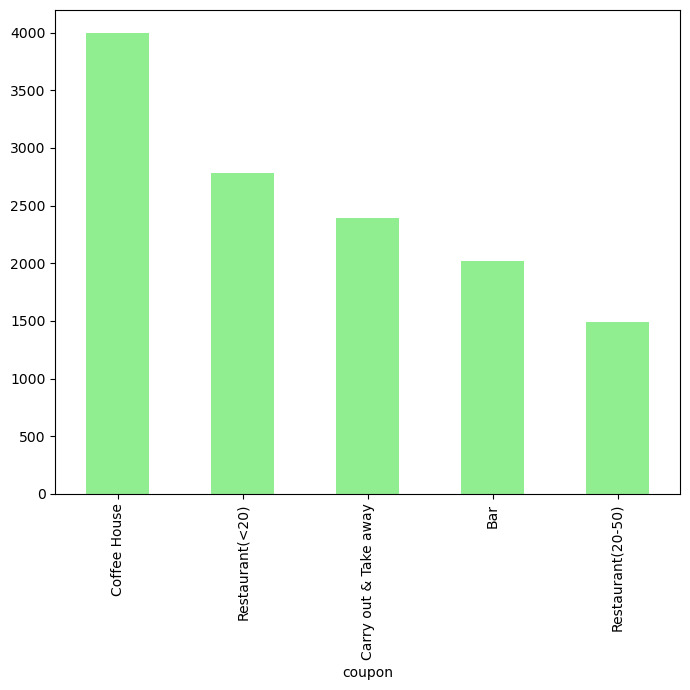

In [ ]:
plt.figure(figsize=(7, 7))
Coupons_info.plot(kind="bar", color="lightgreen")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
Temp_info = data.temperature.value_counts()


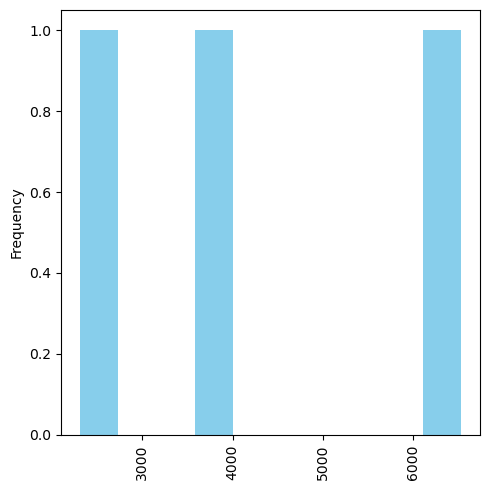

In [ ]:
plt.figure(figsize=(5, 5))
Temp_info.plot(kind="hist", color="skyblue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Investigating the Bar Coupons

1. Create a new DataFrame that contains just the bar coupons.

In [ ]:
Bar_coupons = pd.DataFrame(data.loc[data.coupon == "Bar"])
Bar_coupons.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?

In [ ]:
Bar_coupon_accepts_percentage = (
    Bar_coupons.Y.loc[Bar_coupons.Y == 1].sum() / len(Bar_coupons) * 100
)
print(
    "Total percentage of bar coupons accepted is",
    Bar_coupon_accepts_percentage,
    " percent",
)


Total percentage of bar coupons accepted is 41.00148735746158  percent


Text(0.5, 1.0, 'Bar Coupons Accepted')

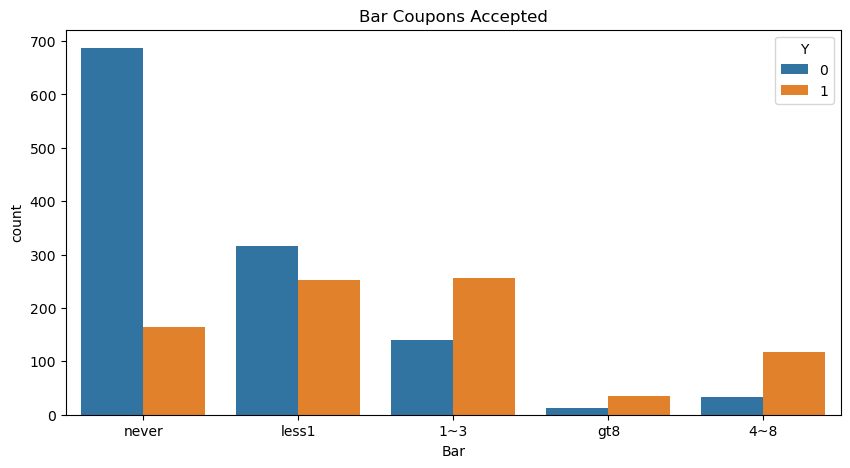

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Bar", hue="Y", data=Bar_coupons)
plt.title("Bar Coupons Accepted")


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.

In [ ]:
Bar_visits_more = Bar_coupons[(Bar_coupons["Bar"].isin(["4~8", "gt8"]))]
Bar_visits_more_percentage = (
    len(Bar_visits_more[Bar_visits_more.Y == 1]) / len(Bar_visits_more) * 100
)
print(
    f"Acceptence Percentage of drivers who is visiting bar more than 3 times in a month: {Bar_visits_more_percentage}"
)


Acceptence Percentage of drivers who is visiting bar more than 3 times in a month: 76.88442211055276


In [ ]:
Bar_visits_less = Bar_coupons[(Bar_coupons["Bar"].isin(["Less1", "never", "1~3"]))]
Bar_visits_less_percentage = (
    len(Bar_visits_less[Bar_visits_less.Y == 1]) / len(Bar_visits_less) * 100
)
print(
    f"Acceptence Percentage of drivers who is visiting bar less than 3 times: {Bar_visits_less_percentage}"
)


Acceptence Percentage of drivers who is visiting bar less than 3 times: 33.733974358974365


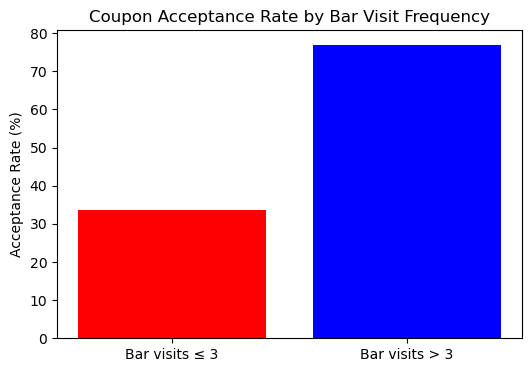

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["Bar visits ≤ 3", "Bar visits > 3"],
    [Bar_visits_less_percentage, Bar_visits_more_percentage],
    color=["red", "blue"],
)
plt.ylabel("Acceptance Rate (%)")
plt.title("Coupon Acceptance Rate by Bar Visit Frequency")
plt.show()


# More reguler drivers are accepting bar coupons than less regular drivers.
# This indicates that drivers who visit bars more frequently are more likely to accept bar coupons.     

- Converting strings inputs in age into integer

In [ ]:
Bar_coupons["age"].replace("50plus", 51, inplace=True)
Bar_coupons["age"].replace("below21", 20, inplace=True)


C:\Users\kottu\AppData\Local\Temp\ipykernel_16260\2031110774.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Bar_coupons['age'].replace('50plus',51,inplace=True)
C:\Users\kottu\AppData\Local\Temp\ipykernel_16260\2031110774.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [ ]:
Bar_coupons["age"].value_counts()


age
21    417
26    395
31    339
51    283
36    209
41    178
46    109
20     87
Name: count, dtype: int64

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others. Is there a difference?

In [ ]:
filtered_coupons_above_25 = Bar_coupons.loc[
    (Bar_coupons["Bar"].isin(["1~3 ", "4~8 ", "gt8"]))
    & (Bar_coupons["age"].astype(int) > 25)
]


In [ ]:
filtered_coupons_above_25_percentage = (
    len(filtered_coupons_above_25[filtered_coupons_above_25.Y == 1])
    / len(filtered_coupons_above_25)
    * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their age is more than 25: {filtered_coupons_above_25_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their age is more than 25: 70.0


In [ ]:
filtered_coupons_below_25 = Bar_coupons.loc[
    (Bar_coupons["Bar"].isin(["less1", "never"]))
    & (Bar_coupons["age"].astype(int) < 25)
]


In [ ]:
filtered_coupons_below_25_percentage = (
    len(filtered_coupons_below_25[filtered_coupons_below_25.Y == 1])
    / len(filtered_coupons_below_25)
    * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their age is less than 25: {filtered_coupons_below_25_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their age is less than 25: 39.329268292682926


Text(0, 0.5, 'Acceptance Rate (%)')

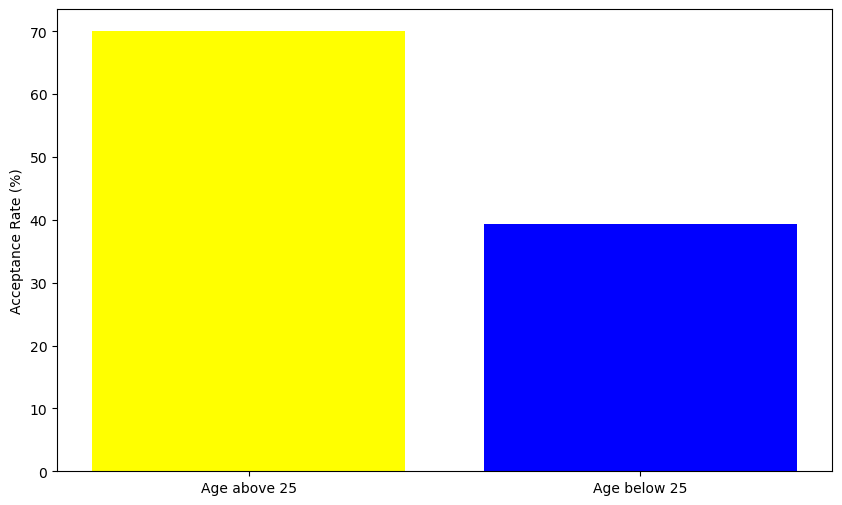

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    ["Age above 25", "Age below 25"],
    [filtered_coupons_above_25_percentage, filtered_coupons_below_25_percentage],
    color=["yellow", "blue"],
)
plt.ylabel("Acceptance Rate (%)")


5. compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

In [ ]:
Bar_coupons["passanger"].value_counts()


passanger
Alone        1200
Friend(s)     337
Partner       274
Kid(s)        206
Name: count, dtype: int64

In [ ]:
Bar_coupons["occupation"].value_counts()


occupation
Unemployed                                   301
Student                                      251
Computer & Mathematical                      232
Sales & Related                              178
Education&Training&Library                   140
Management                                   119
Office & Administrative Support              105
Arts Design Entertainment Sports & Media     100
Business & Financial                          89
Retired                                       75
Food Preparation & Serving Related            48
Healthcare Support                            44
Community & Social Services                   44
Healthcare Practitioners & Technical          41
Transportation & Material Moving              35
Legal                                         34
Architecture & Engineering                    27
Personal Care & Service                       27
Protective Service                            27
Construction & Extraction                     24
Life Phys

In [ ]:
condition_of_q5 = Bar_coupons[
    Bar_coupons["Bar"].isin(["1~3 ", "4~8 ", "gt8"])
    & (Bar_coupons["passanger"] != "kid(s)")
    & (Bar_coupons["occupation"] != "Farming Fishing & Forestry")
]
condition_of_q5_percentage = (
    len(condition_of_q5[condition_of_q5.Y == 1]) / len(condition_of_q5) * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their occupation is not Farming Fishing & Forestry and passanger is not kid(s): {condition_of_q5_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their occupation is not Farming Fishing & Forestry and passanger is not kid(s): 73.46938775510205


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.

In [ ]:
Bar_coupons["maritalStatus"].value_counts()


maritalStatus
Married partner      882
Single               661
Unmarried partner    378
Divorced              75
Widowed               21
Name: count, dtype: int64

In [ ]:
condition_6_1 = Bar_coupons[
    Bar_coupons["Bar"].isin(["1~3 ", "4~8 ", "gt8"])
    & (Bar_coupons["passanger"] != "kid(s)")
    & (Bar_coupons["maritalStatus"] != "Widowed")
]
condition_6_1_percentage = (
    len(condition_6_1[condition_6_1.Y == 1]) / len(condition_6_1) * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their marital status is not Widowed and passanger is not kid(s): {condition_6_1_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their marital status is not Widowed and passanger is not kid(s): 73.46938775510205


In [ ]:
condition_6_2 = Bar_coupons[
    Bar_coupons["Bar"].isin(["1~3 ", "4~8 ", "gt8"])
    & (Bar_coupons["age"].astype(int) < 30)
]
condition_6_2_percentage = (
    len(condition_6_2[condition_6_2.Y == 1]) / len(condition_6_2) * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their age is less than 30: {condition_6_2_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their age is less than 30: 81.08108108108108


In [ ]:
condition_6_3 = Bar_coupons[
    Bar_coupons.RestaurantLessThan20.isin(["4~8", "gt8"])
    & Bar_coupons["income"].isin(
        ["$25000 - $37499", "$12500 - $24999 ", "$37500 - $49999", "Less than $12500"]
    )
]
condition_6_3_percentage = (
    len(condition_6_3[condition_6_3.Y == 1]) / len(condition_6_3) * 100
)
print(
    f"Percentage of drivers who is visiting bar more than 1 time and their income is less than $50000: {condition_6_3_percentage}"
)


Percentage of drivers who is visiting bar more than 1 time and their income is less than $50000: 46.12244897959184


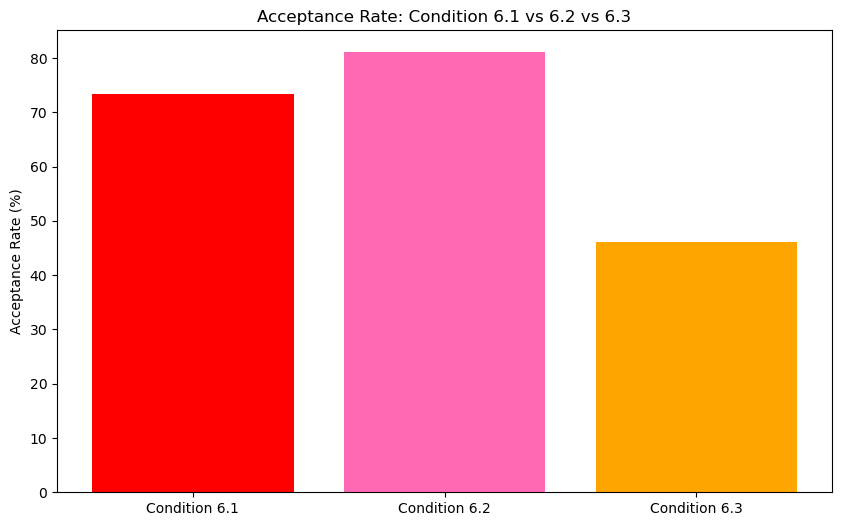

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    ["Condition 6.1", "Condition 6.2", "Condition 6.3"],
    [condition_6_1_percentage, condition_6_2_percentage, condition_6_3_percentage],
    color=["red", "hotpink", "orange"],
)
plt.ylabel("Acceptance Rate (%)")
plt.title("Acceptance Rate: Condition 6.1 vs 6.2 vs 6.3")
plt.show()


7. Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

- Based on these observations, drivers who accepted bar coupons are more likely to be regular, especially those who visit bars more than once a month. Acceptance rates are higher among drivers aged less than 30.
- then marital status is not Widowed and passanger is not kid
- and then drivers whose income is less than $50000

8. Independent Investigation

- Identifying coupon accepting patterns based on gender

In [ ]:
Bar_coupons["maritalStatus"].value_counts()


maritalStatus
Married partner      882
Single               661
Unmarried partner    378
Divorced              75
Widowed               21
Name: count, dtype: int64

In [ ]:
II_Condition_1 = Bar_coupons[
    Bar_coupons["gender"].isin(["Female"])
    & Bar_coupons["maritalStatus"].isin(["Single"])
]
II_Condition_1_percentage = (
    len(II_Condition_1[II_Condition_1.Y == 1]) / len(II_Condition_1) * 100
)
print(
    f"Percentage of female drivers who is single and accepted the coupon: {II_Condition_1_percentage}"
)


Percentage of female drivers who is single and accepted the coupon: 45.593869731800766


In [ ]:
II_Condition_2 = Bar_coupons[
    Bar_coupons["gender"].isin(["Male"]) & Bar_coupons["maritalStatus"].isin(["Single"])
]
II_Condition_2_percentage = (
    len(II_Condition_2[II_Condition_2.Y == 1]) / len(II_Condition_2) * 100
)
print(
    f"Percentage of female drivers who is single and accepted the coupon: {II_Condition_2_percentage}"
)


Percentage of female drivers who is single and accepted the coupon: 60.5


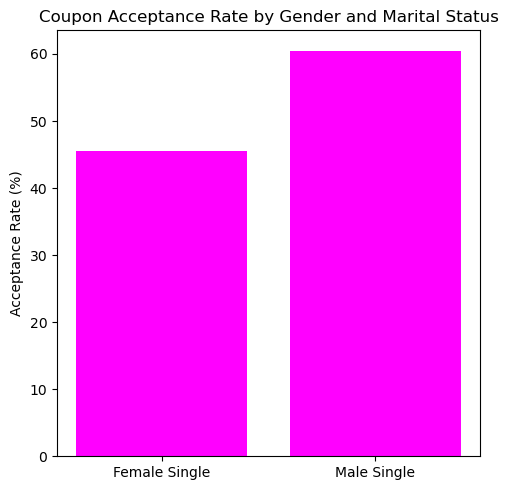

In [ ]:
plt.figure(figsize=(5, 5))
plt.bar(
    ["Female Single", "Male Single"],
    [II_Condition_1_percentage, II_Condition_2_percentage],
    color="magenta",
)
plt.ylabel("Acceptance Rate (%)")
plt.title("Coupon Acceptance Rate by Gender and Marital Status")
plt.tight_layout()
plt.show()


single drivers, particularly males, show higher acceptance rates.

# Independent Investigation
- Problem Statement: Effect of Weather and Time 
    - Investigate if weather of day influences coupon acceptance.
    - Example: Are coupons more likely to be accepted on sunny days?                    

In [ ]:
data["weather"].value_counts()


weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64

In [ ]:
sunny_coupons = data[data["weather"] == "Sunny"]
sunny_coupons_percentage = (
    len(sunny_coupons[sunny_coupons["Y"] == 1]) / len(sunny_coupons) * 100
)
print(f"Percentage of coupons accepted on sunny days: {sunny_coupons_percentage}")


Percentage of coupons accepted on sunny days: 59.47959082331909


In [ ]:
snowy_coupons = data[data["weather"] == "Snowy"]
snowy_coupons_percentage = (
    len(snowy_coupons[snowy_coupons["Y"] == 1]) / len(snowy_coupons) * 100
)
print(f"Percentage of coupons accepted on snowy days: {snowy_coupons_percentage}")


Percentage of coupons accepted on snowy days: 47.046263345195726


In [ ]:
rainy_coupons = data[data["weather"] == "Rainy"]
rainy_coupons_percentage = (
    len(rainy_coupons[rainy_coupons["Y"] == 1]) / len(rainy_coupons) * 100
)
print(f"Percentage of coupons accepted on rainy days: {rainy_coupons_percentage}")


Percentage of coupons accepted on rainy days: 46.28099173553719


Text(0, 0.5, 'Count')

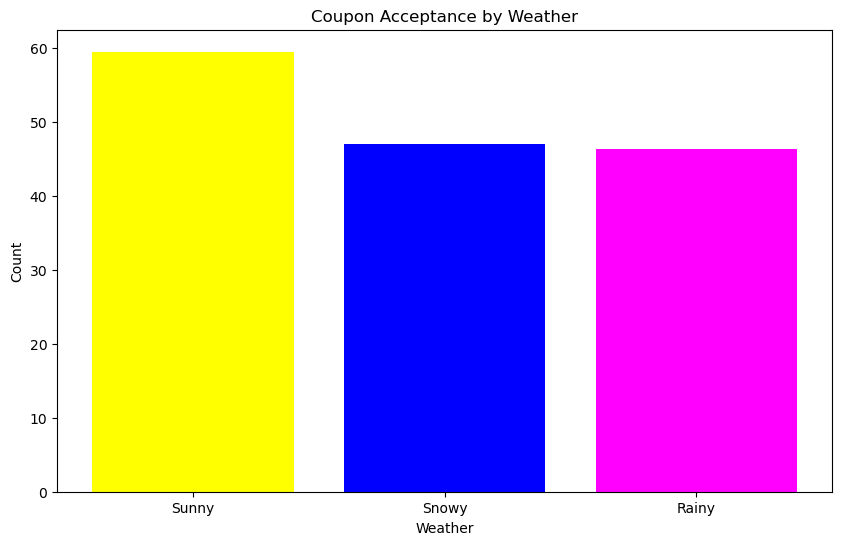

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    ["Sunny", "Snowy", "Rainy"],
    [sunny_coupons_percentage, snowy_coupons_percentage, rainy_coupons_percentage],
    color=["yellow", "blue", "magenta"],
)
plt.ylabel("Acceptance Rate (%)")
plt.title("Coupon Acceptance by Weather")
plt.xlabel("Weather")
plt.ylabel("Count")


- Most of the coupons were accepted on a sunny day when compare to rainy and snowy day.
- Environmental factors like sunny weather also seem to positively influence coupon acceptance.
